# SPIKE DETECTION 

Este notebook implementa el pipeline de Spike Detection para pasar de una "Raw Signal" del archivo .ns6 a una matriz MUA que sirva como input para el entrenamiento de la SNN 

**Flujo:**
0. Downsampling 30khz-10khz
1. Filter MAD
2. Spike Emphasis
3. Threshold
4. Threshold update
5. Spike Detection
6. Refractory Period
7. Spike Bins

Frecuencias encontradas: {1000, 30000}
Señales a 30 kHz encontradas: 96

Canal 0: 30096285 muestras, 1003.2095 1/Hz

Antes downsampling: 30096285 muestras
Después downsampling: 10032095 muestras


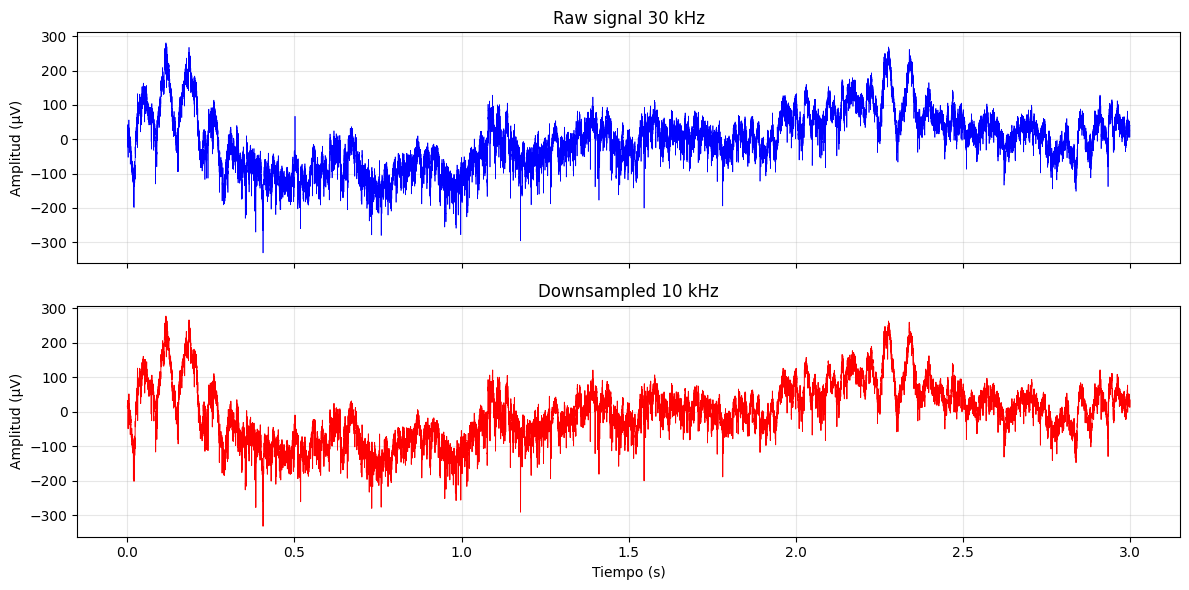

In [1]:

# ============================================================
# PASO 0: Cargar señal raw (.ns6) + DOWNSAMPLING 30 kHz--> 10 kHz
# ============================================================

import numpy as np                    # Librería para operaciones numéricas (arrays, matrices)
import matplotlib.pyplot as plt       # Librería para gráficos
from scipy.signal import decimate     # Función para reducir frecuencia de muestreo
import neo                            # Librería especializada en datos neurofisiológicos
from pathlib import Path              # Manejo de rutas de archivos (más elegante que strings)

data_path = Path("C:/Proyectos/TFG/data/i140703-001.ns6")
fs_original = 30000  # Hz - Frecuencia original del Utah Array (30 kHz)
fs_target = 10000    # Hz - Frecuencia objetivo después de downsampling--: Suficiente para detectar spikes (duran ~1-2 ms ≈ 500-1000 Hz)
fs_output = 1000     # Hz - Frecuencia final del MUA (1 bin = 1 ms = 1 muestra)



#───────────────────── 1) Leo el archivo  y verifico las freqs disponibles─────────────────────

reader = neo.io.BlackrockIO(filename=str(data_path))             #con str convierto a string (lo necesita neo)
blk = reader.read_block(lazy=True, signal_group_mode='split-all') #lazy:no carga todo en memoria aún, solo metadata  y split-all: separa cada canal en señales individuales
seg = blk.segments[0] # Un "segment" en Neo es un período continuo de grabación--[0] porque solo hay un segmento en este archivo

""""
ESTRUCTURA DE NEO:
Block (grabación completa)
└── Segment (período continuo)
    ├── AnalogSignal 0 (canal 0)
    ├── AnalogSignal 1 (canal 1)
    ├── ...
    └── AnalogSignal 95 (canal 95)
"""

freqs = set(int(s.sampling_rate.rescale('Hz').magnitude) for s in seg.analogsignals)
print(f"Frecuencias encontradas: {freqs}")


#─────────────────────2) Selecciono las señales a 30 kHz ─────────────────────
 #Filtro señales porque el archivo .ns6 puede contener señales auxiliares a otras frecuencias. Solo queremos los 96 canales neurales a 30 kHz.

signals_30k = [s for s in seg.analogsignals if int(s.sampling_rate.rescale('Hz').magnitude) == fs_original]
print(f"Señales a 30 kHz encontradas: {len(signals_30k)}")


#─────────────────────3) Elijo el canal 0 (por ejemplo, y mas adelante lo hare para los 96)─────────────────────
canal = 0
raw_signal = signals_30k[canal].load()  #AQUÍ se carga realmente los datos en memoria (antes era lazy)
print(f"\nCanal {canal}: {raw_signal.shape[0]} muestras, {raw_signal.duration}")


#─────────────────────4) Downsampling: 30 kHz -> 10 kHz (factor = 3)─────────────────────
# Uso decimate de SciPy, que aplica un filtro anti-aliasing antes de submuestrear. 
# Esto elimina componentes de frecuencia por encima de 5 kHz (la mitad de 10 kHz) para evitar aliasing.
# Reducir a 10 kHz es suficiente porque los spikes tienen ancho de ~1-2 ms, equivalente a ~500-1000 Hz."

data_30k = raw_signal.magnitude.flatten() #.magnitude: Extrae solo los valores numéricos (quita unidades)
                                          #.flatten(): Convierte de shape (N, 1) a (N,) (array 1D)
data_10k = decimate(data_30k, q=3, ftype='fir') #primero filtra frecuencias >5 kHz, luego submuestrea.
                                                #fir: Tipo de filtro (Finite Impulse Response, más estable)
print(f"\nAntes downsampling: {len(data_30k)} muestras")
print(f"Después downsampling: {len(data_10k)} muestras") # 30,000 muestras/s ÷ 3 = 10,000 muestras/s





# ---------------------------------------- GRAFICA 1: Comparar antes/después downsampling -------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
t_max = 3.0  # ver solo 3 segundos
idx_30k = int(t_max * fs_original)
idx_10k = int(t_max * fs_target)
ax1.plot(np.arange(idx_30k)/fs_original, data_30k[:idx_30k], 'b', lw=0.5)
ax1.set_ylabel('Amplitud (μV)')
ax1.set_title('Raw signal 30 kHz')
ax1.grid(alpha=0.3)
ax2.plot(np.arange(idx_10k)/fs_target, data_10k[:idx_10k], 'r', lw=0.7)
ax2.set_ylabel('Amplitud (μV)')
ax2.set_xlabel('Tiempo (s)')
ax2.set_title('Downsampled 10 kHz')
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Media antes: -0.08 μV → después: -0.00 μV


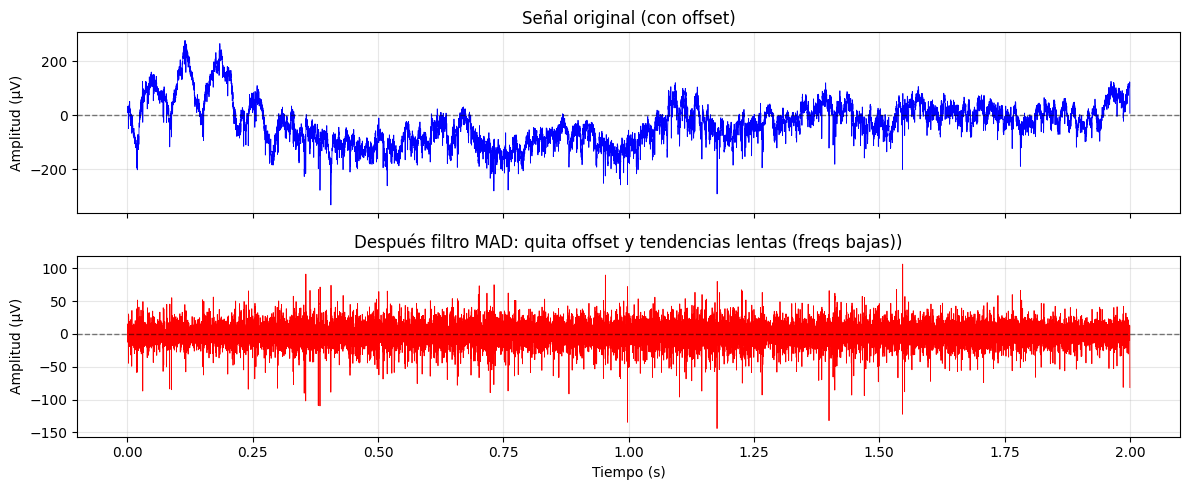

In [2]:
# ===============================================================
# Paso 1· FILTER MAD- quita componentes de baja frecuencia
# ===============================================================
# MAD(n) = x(n) - 1/2[x(n-1) + x(n-2)]
# Objetivo: Eliminar componentes de baja frecuencia (restando un promedio de las 2 muestras anteriores-->Solo sumas y shifts)


#1) Extraigo datos de la señal a 10 kHz
#data_10k_array = data_10k.copy()  # Crea una copia independiente, así no modificamos data_10k original
fs = 10000  
#print(f"\n Señal de entrada:")
#print(f"   Muestras: {len(data_10k_array):,}")
#print(f"   Fs: {fs} Hz")
#print(f"   Duración: {len(data_10k_array)/fs:.2f} s")

# 2) Funcion del filtro MAD: para quitar DC y bajas frecuencias
# Señal entrada--> signal: numpy array
# Señal salida(filtrada)--> filtered: numpy array (mismo tamaño que entrada)

def filtro_mad(signal): 
    N = len(signal)
    filtered = np.zeros(N) #Array de ceros del mismo tamaño (para guardar resultado)
    
    # Las primeras 2 muestras no tienen historial suficiente
    filtered[0] = signal[0]
    filtered[1] = signal[1] - 0.5 * signal[0]
    
    # A partir de n=2, aplico la fórmula completa
    for n in range(2, N):
        filtered[n] = signal[n] - 0.5 * (signal[n-1] + signal[n-2])
    
    return filtered

# 3) Aplico el filtro con la funcion anterior con los datos a 10 kHz
signal_mad = filtro_mad(data_10k) 
print(f"Media antes: {np.mean(data_10k):.2f} μV → después: {np.mean(signal_mad):.2f} μV")



#---------------------------------------------------------------Gráfica 2: Original vs Filtrada ---------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
t_vis = 2.0  # ver 2 segundos
time_10k = np.arange(len(data_10k)) / fs_target
idx = int(t_vis * fs)
t = time_10k[:idx]

ax1.plot(t, data_10k[:idx], 'b', lw=0.6)
ax1.set_ylabel('Amplitud (μV)')
ax1.set_title('Señal original (con offset)')
ax1.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
ax1.grid(alpha=0.3)

ax2.plot(t, signal_mad[:idx], 'r', lw=0.6)
ax2.set_ylabel('Amplitud (μV)')
ax2.set_xlabel('Tiempo (s)')
ax2.set_title('Después filtro MAD: quita offset y tendencias lentas (freqs bajas))')
ax2.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Ventana de actualización: 8912 muestras (0.89 s)
Número de ventanas: 10032095
   Ventana 0: media=12.54 μV → threshold=50.17 μV
   Ventana 1: media=12.96 μV → threshold=51.83 μV
   Ventana 2: media=10.31 μV → threshold=41.26 μV
Threshold medio: 45.86 μV
Rango threshold: [36.99, 58.09] μV


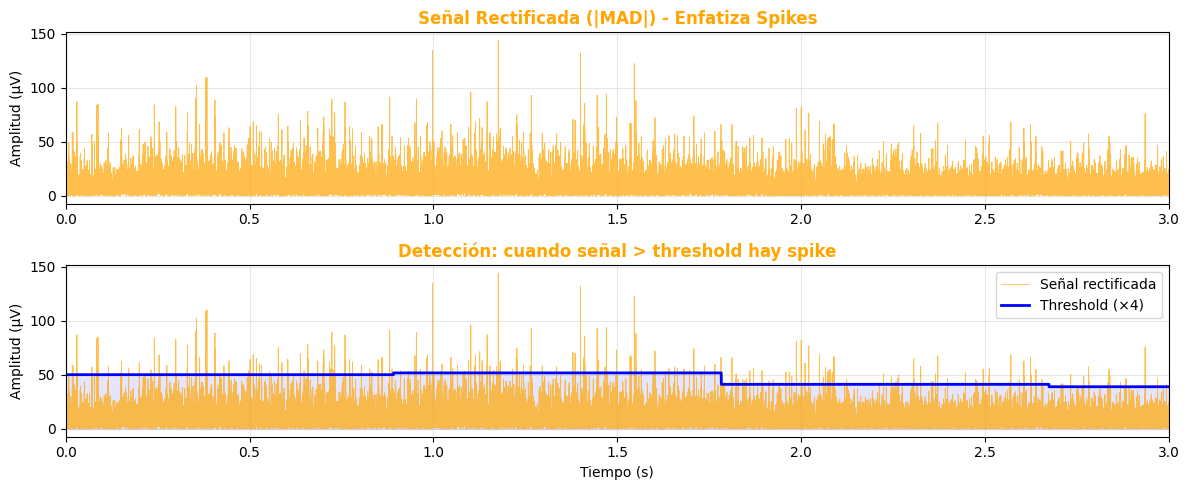

   Muestras totales: 10,032,095
   Muestras > threshold: 110,503 (1.10%)
   Ratio señal/threshold promedio: 0.25


In [3]:
# =====================================================================================
# PASO 2: SPIKE EMPHASIS (Rectificación) 
# PASO 3 y 4: THRESHOLD + THRESHOLD UPDATE
# =====================================================================================
# Objetivo: Enfatizar la forma del spike
# Los spikes pueden ser positivos o negativos (depende de la orientación del electrodo respecto a la neurona)
# Queremos detectar ambos tipos con el mismo método -->Solución: Tomar valor absoluto → Todo se vuelve positivo


#1) Rectificar = valor absoluto, para enfatizar los picos
signal_rect = np.abs(signal_mad)

#2) Calculo threshold adaptativo--> se actualiza cada 8912 muestras (~0.89 s a 10 kHz)
update_interval = 8912  #8912 muestras ÷ 10,000 Hz = 0.8912 s
threshold_mult = 4      #factor multiplicadorpara evitar falsos positivos, evita detectar ruido

N = len(signal_rect)
n_ventanas = int(np.ceil(N / update_interval))  #Cuántas ventanas de 8912 muestras caben
                                                #np.ceil(): Redondea hacia arriba (última ventana puede ser más corta)
threshold_array = np.zeros(N)                   # Array para almacenar threshold en cada ventana

print(f"Ventana de actualización: {update_interval} muestras ({update_interval/fs:.2f} s)")
print(f"Número de ventanas: {N}")

#3) Calculo el threshold por ventanas
for i in range(n_ventanas):
    start = i * update_interval
    end = min((i + 1) * update_interval, N) #usa min para no exceder el array en la última ventana
    
    # Threshold= media de la ventana × 4
    ventana = signal_rect[start:end]
    mean_ventana = np.mean(ventana)
    thresh_ventana = mean_ventana * threshold_mult
    threshold_array[start:end] = thresh_ventana       # Asigno threshold a toda la ventana (valor cte por tramos)


    if i < 3:  # Muestro las primeras 3 ventanas
            print(f"   Ventana {i}: media={mean_ventana:.2f} μV → threshold={thresh_ventana:.2f} μV")

#NOTA: Cada "escalón" en la gráfica azul representa una ventana de 0.89 s.
print(f"Threshold medio: {np.mean(threshold_array):.2f} μV")
print(f"Rango threshold: [{np.min(threshold_array):.2f}, {np.max(threshold_array):.2f}] μV")




#--------------------------------------------------------- GRAFICA 1: Señal rectificada + threshold -------------------------------------------
fig, ax = plt.subplots(2,1,figsize=(12, 5))
t_vis = 3.0  # ver 3 segundos
idx = int(t_vis * fs)
t = time_10k[:idx]

ax[0].plot(t, signal_rect[:idx], 'orange', lw=0.6, alpha=0.7)
ax[0].set_title('Señal Rectificada (|MAD|) - Enfatiza Spikes', fontweight='bold', fontsize=12, color='orange')
ax[0].set_ylabel('Amplitud (μV)', fontsize=10)
ax[0].grid(True, alpha=0.3)
ax[0].set_xlim(0, t_vis)

ax[1].plot(t, signal_rect[:idx], 'orange', lw=0.6, alpha=0.7, label='Señal rectificada')
ax[1].plot(t, threshold_array[:idx], 'b', lw=2, label='Threshold (×4)')
ax[1].fill_between(t, 0, threshold_array[:idx], color='blue', alpha=0.1)
ax[1].set_xlabel('Tiempo (s)')
ax[1].set_ylabel('Amplitud (μV)')
ax[1].set_title('Detección: cuando señal > threshold hay spike',fontweight='bold', fontsize=12, color='orange')
ax[1].legend()
ax[1].grid(True,alpha=0.3)
ax[1].set_xlim(0, t_vis)

plt.tight_layout()
plt.show()

# ---------------------------------------- ANÁLISIS: Cuántos puntos superan el threshold -------------------------------------------
detections = signal_rect > threshold_array
n_detections = np.sum(detections)
percentage = (n_detections / N) * 100

print(f"   Muestras totales: {N:,}")
print(f"   Muestras > threshold: {n_detections:,} ({percentage:.2f}%)")
print(f"   Ratio señal/threshold promedio: {np.mean(signal_rect)/np.mean(threshold_array):.2f}")




Cruces de umbral detectados: 110,503
(pueden incluir múltiples detecciones del mismo spike)


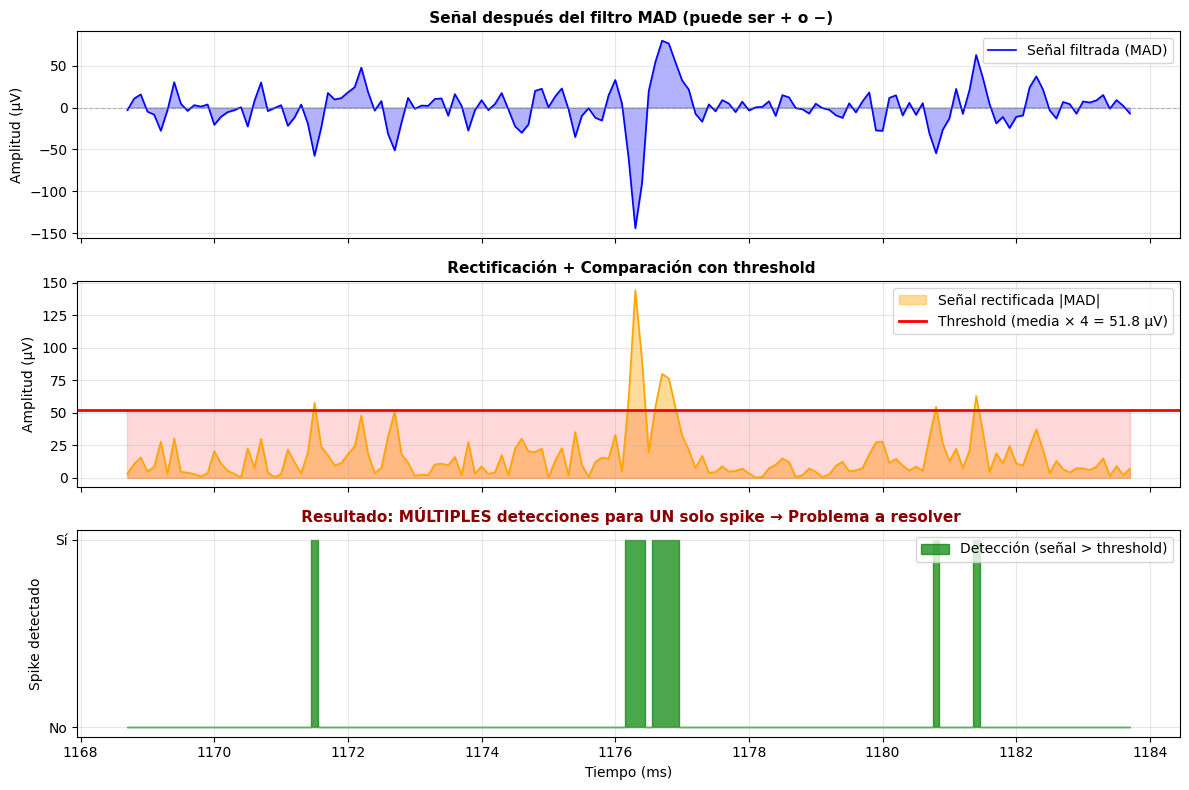


──────────────────────────────────────────────────
En esta ventana de 15 ms:
  • Spikes reales: 1
  • Detecciones: 10
  • Problema: Ratio 10:1
──────────────────────────────────────────────────
→ Problema: Un spike dura ~10-20 muestras, así que genera ~10-20 detecciones por spike real.
→ Solución: Período refractario (siguiente celda)


In [4]:
# ===============================================================
# PASO 5: SPIKE DETECTION  
# ===============================================================
# Detección: Cuando señal_rectificada > threshold → SPIKE
# Aquí pueden haber múltiples detecciones del mismo spike--esto se corrige en el paso 6


spike_crossings = signal_rect > threshold_array
spike_indices_raw = np.where(spike_crossings)[0] 
    #np.where devuelve los índices donde la condición es True
    #[0] para obtener solo los índices (no la tupla completa)
    #Resultado: array de índices donde hay cruces de umbral

print(f"Cruces de umbral detectados: {len(spike_indices_raw):,}")
print(f"(pueden incluir múltiples detecciones del mismo spike)")

#Convierte índices (muestras) ---> tiempos (segundos)
spike_times_raw = spike_indices_raw / fs

# ---------------------------------------------------- GRAFICA 1: Zoom en una región con spikes ---------------------------------------------------
#Busco un spike grande para hacer zoom
idx_spike = np.argmax(signal_rect[:int(3*fs)])
t_center = idx_spike / fs
t_window = 0.015  # ventana de 15 ms 
idx_start = max(0, int((t_center - t_window/2) * fs))
idx_end = min(N, int((t_center + t_window/2) * fs))
t_zoom = time_10k[idx_start:idx_end]

#) Filtro spikes en esta ventana
signal_zoom = signal_mad[idx_start:idx_end]
rect_zoom = signal_rect[idx_start:idx_end]
thresh_zoom = threshold_array[idx_start:idx_end]
crossings_zoom = spike_crossings[idx_start:idx_end]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# ------------PANEL 1: Señal MAD original----------
ax1 = axes[0]
ax1.plot(t_zoom * 1000, signal_zoom, 'b', lw=1.2, label='Señal filtrada (MAD)')
ax1.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
ax1.fill_between(t_zoom * 1000, signal_zoom, 0, alpha=0.3, color='blue')
ax1.set_ylabel('Amplitud (μV)')
ax1.set_title(' Señal después del filtro MAD (puede ser + o −)', fontsize=11, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)

# -----------PANEL 2: Señal rectificada + threshold-------
ax2 = axes[1]
ax2.fill_between(t_zoom * 1000, rect_zoom, 0, alpha=0.4, color='orange', label='Señal rectificada |MAD|')
ax2.plot(t_zoom * 1000, rect_zoom, 'orange', lw=1.2)
ax2.axhline(thresh_zoom[0], color='red', ls='-', lw=2, label=f'Threshold (media × 4 = {thresh_zoom[0]:.1f} μV)')
ax2.fill_between(t_zoom * 1000, thresh_zoom, 0, alpha=0.15, color='red')
ax2.set_ylabel('Amplitud (μV)')
ax2.set_title(' Rectificación + Comparación con threshold', fontsize=11, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

# -----------PANEL 3: Detecciones de cruces de umbral -------
ax3 = axes[2]
ax3.fill_between(t_zoom * 1000, crossings_zoom.astype(int), 0, 
                  step='mid', alpha=0.7, color='green', label='Detección (señal > threshold)')
ax3.set_ylabel('Spike detectado')
ax3.set_xlabel('Tiempo (ms)')
ax3.set_title(' Resultado: MÚLTIPLES detecciones para UN solo spike → Problema a resolver', 
              fontsize=11, fontweight='bold', color='darkred')
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['No', 'Sí'])
ax3.legend(loc='upper right')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()
#----------------------------------------------------------------
n_detections_zoom = np.sum(crossings_zoom)
ax3.annotate(f'{n_detections_zoom} muestras detectadas\npara 1 solo spike', 
             xy=(t_center * 1000, 1), xytext=(t_center * 1000 + 2, 0.6),
             fontsize=10, color='darkred', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5))
print(f"\n{'─'*50}")
print(f"En esta ventana de {t_window*1000:.0f} ms:")
print(f"  • Spikes reales: 1")
print(f"  • Detecciones: {n_detections_zoom}")
print(f"  • Problema: Ratio {n_detections_zoom}:1")
print(f"{'─'*50}")
print("→ Problema: Un spike dura ~10-20 muestras, así que genera ~10-20 detecciones por spike real.")
print("→ Solución: Período refractario (siguiente celda)")




Período refractario: 1.0 ms = 10 muestras

Spikes detectados CON refractario: 65,415
Spikes eliminados por refractario: 45,088
Tasa de spikes: 65.21 spikes/s

Duración de la grabación: 1003.21 s
Primeros 5 tiempos (s): [0.0181 0.0198 0.0305 0.0712 0.0781]
Últimos 5 tiempos (s): [1003.0819 1003.0945 1003.1077 1003.1104 1003.1783]

ISI medio: 15.34 ms
ISI mínimo: 1.00 ms (debe ser >= 1.0 ms)


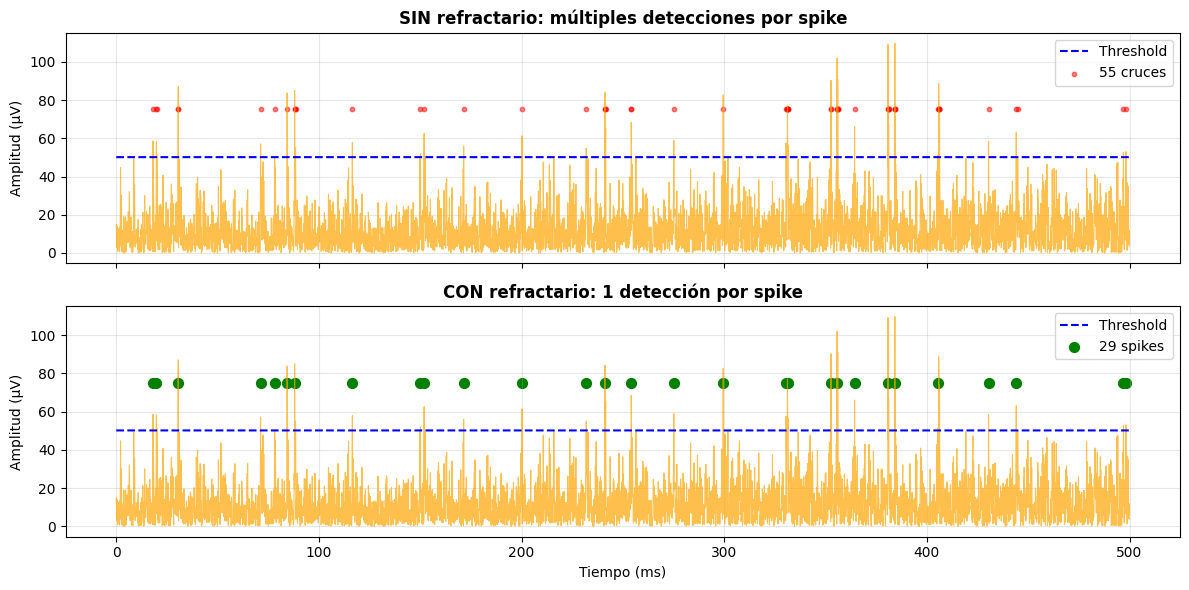

In [5]:
# ===============================================================
# PASO 6:  REFRACTARY PERIOD
# ===============================================================
# Período refractario:Es un tiempo de bloqueo después de cada spike detectado
# Output: Lista de timestamps donde ocurren spikes

refrac_period = 0.001  # en seg
refrac_samples = int(refrac_period * fs)  # 10 muestras (a 10 kHz)
print(f"Período refractario: {refrac_period*1000} ms = {refrac_samples} muestras")

# 1)Aplicar refractario 
spike_indices = []
last_spike = -refrac_samples  #Inicializar con valor negativo para que el primer spike siempre sea aceptado

for i in spike_indices_raw:
    if (i - last_spike) >= refrac_samples:     #Si la distancia es ≥ 10 muestras (1 ms) acepta el spike
        spike_indices.append(i) #acepto spike  # if (tiempo_actual - último_spike) >= 1ms:
                                                    #aceptar spike
                                                    #actualizar último_spike
        last_spike = i  # actualizar

spike_indices = np.array(spike_indices)
spike_times = spike_indices / fs #Convierte  índices a segundos

print(f"\nSpikes detectados CON refractario: {len(spike_indices):,}")
print(f"Spikes eliminados por refractario: {len(spike_indices_raw) - len(spike_indices):,}")
print(f"Tasa de spikes: {len(spike_indices) / (N/fs):.2f} spikes/s")
print(f"\nDuración de la grabación: {N/fs:.2f} s")
print(f"Primeros 5 tiempos (s): {spike_times[:5]}")
print(f"Últimos 5 tiempos (s): {spike_times[-5:]}")

# 2)Verificación: Calcular ISI (Inter-Spike Interval)
if len(spike_times) > 1:
    isi = np.diff(spike_times) * 1000  # (en ms) esto calcula la diferencia entre spikes consecutivos
    print(f"\nISI medio: {np.mean(isi):.2f} ms")
    print(f"ISI mínimo: {np.min(isi):.2f} ms (debe ser >= 1.0 ms)")

# ---------------------------------------------- GRÁFICA: Comparar antes/después refractario -------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

t_vis = 0.5  # Solo 500 ms para ver mejor
idx = int(t_vis * fs)
t = time_10k[:idx]



# --------------------------Panel 1: Sin refractario-----------------------------
ax1 = axes[0]
ax1.plot(t * 1000, signal_rect[:idx], 'orange', lw=0.8, alpha=0.7)
ax1.plot(t * 1000, threshold_array[:idx], 'b--', lw=1.5, label='Threshold')
spikes_raw_vis = spike_times_raw[spike_times_raw < t_vis]
ax1.scatter(spikes_raw_vis * 1000, np.ones_like(spikes_raw_vis) * threshold_array[0] * 1.5, 
            c='red', s=10, alpha=0.5, label=f'{len(spikes_raw_vis)} cruces')
ax1.set_ylabel('Amplitud (μV)')
ax1.set_title('SIN refractario: múltiples detecciones por spike', fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)

# ---------------------------Panel 2: Con refractario-------------------------------
ax2 = axes[1]
ax2.plot(t * 1000, signal_rect[:idx], 'orange', lw=0.8, alpha=0.7)
ax2.plot(t * 1000, threshold_array[:idx], 'b--', lw=1.5, label='Threshold')
spikes_clean_vis = spike_times[spike_times < t_vis]
ax2.scatter(spikes_clean_vis * 1000, np.ones_like(spikes_clean_vis) * threshold_array[0] * 1.5,
            c='green', s=50, label=f'{len(spikes_clean_vis)} spikes')
ax2.set_ylabel('Amplitud (μV)')
ax2.set_xlabel('Tiempo (ms)')
ax2.set_title('CON refractario: 1 detección por spike', fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Duración total: 1003.21 s
Bins de 1.0 ms → 1,003,210 bins

DISTRIBUCIÓN DE SPIKES POR BIN:
   0 spike(s): 937,804 bins (93.48%)
   1 spike(s): 65,406 bins (6.52%)

Bins con spikes: 65,406 (6.52%)
Bins vacíos: 937,804 (93.48%)


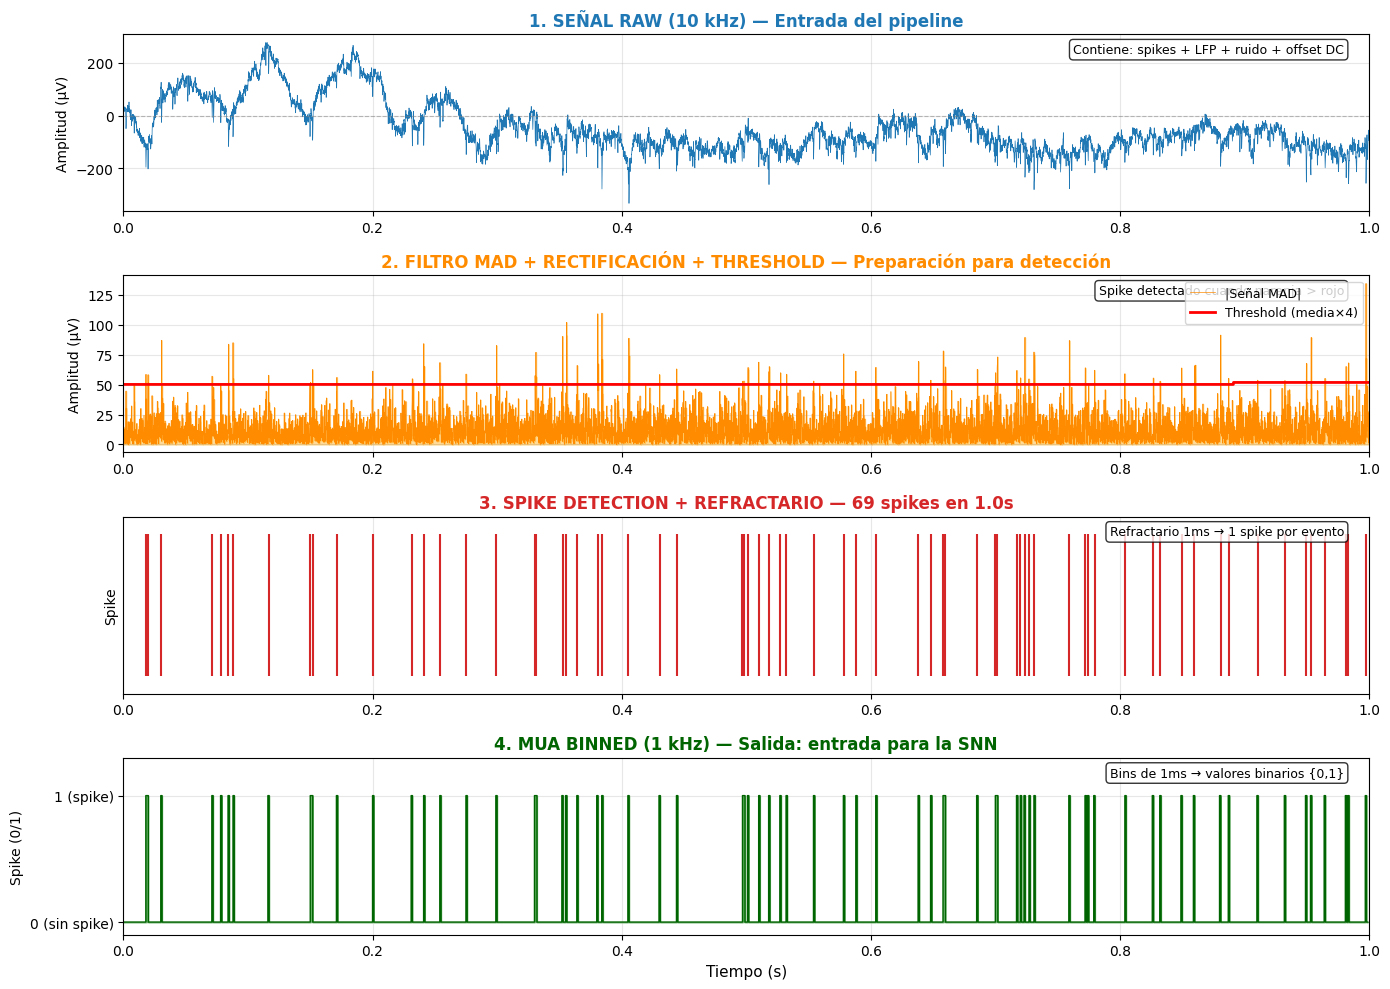


════════════════════════════════════════════════════════════
RESUMEN DEL PIPELINE (1 canal)
════════════════════════════════════════════════════════════
  1) Raw 10kHz:     10,000 muestras
  2) Filtrado MAD:  Elimina DC y LFP
  3) Detección:     69 spikes (con refractario 1ms)
  4) MUA 1kHz:      1,000 bins, 69 activos (6.9%)
════════════════════════════════════════════════════════════


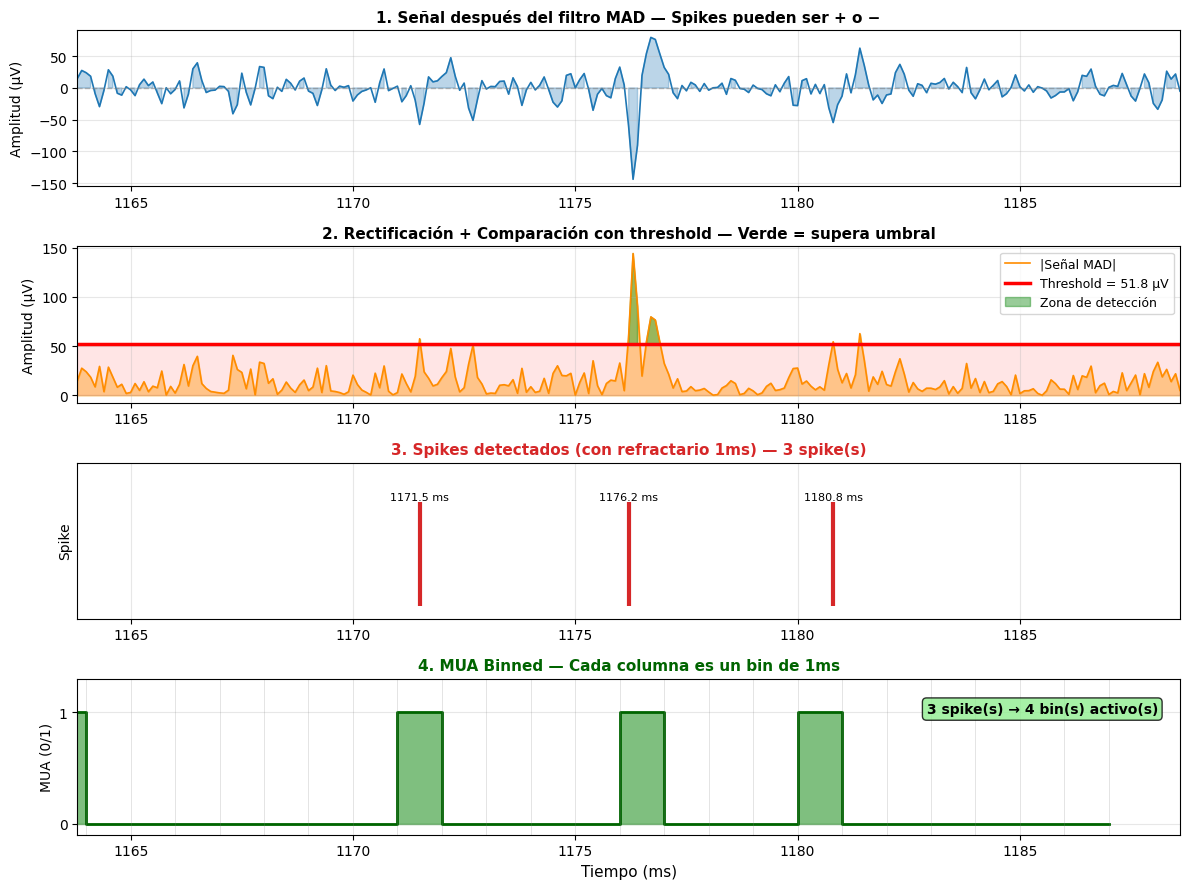


════════════════════════════════════════════════════════════
ZOOM: Ventana de 25 ms centrada en t=1176.3 ms
════════════════════════════════════════════════════════════
  Spikes detectados: 3
  Bins MUA activos:  4
  Correspondencia:   1 spike = 1 bin (gracias al refractario)
════════════════════════════════════════════════════════════


In [6]:
# ===============================================================
# PASO 7: SPIKE BINS (BINNING)
# ===============================================================
# Objetivo: spike_times: (timestamps irregulares :( ) →  MUA (señal regular 1 kHz)
# Cada bin de 1 ms puede tener 0 o 1 (binario)
# Resultado: Array MUA de valores binarios {0, 1} a 1 kHz.

bin_size = 0.001  # 1 ms
output_fs = 1000  # 1 kHz

#1)Calcular cuántos bins necesitamos
duracion_total = N / fs
n_bins = int(np.ceil(duracion_total / bin_size))
print(f"Duración total: {duracion_total:.2f} s")
print(f"Bins de {bin_size*1000} ms → {n_bins:,} bins")

# 2)Crear array para MUA binario
MUA = np.zeros(n_bins, dtype=np.int8)

# 3)Convierte cada tiempo de spike (segundos) a su bin correspondiente
spike_bins = (spike_times / bin_size).astype(int)
"""
spike_indices
spike_times:  [0.0234, 0.0891, 0.1456, ...]  (segundos)
                 ↓        ↓        ↓
spike_bins:   [23,      89,      145,    ...]  (índices de bin)
"""

# 4)Contar spikes por bin
for bin_idx in spike_bins:
    if bin_idx < n_bins:
        MUA[bin_idx] = 1
time_mua = np.arange(n_bins) * bin_size # Vector de tiempo para MUA


#5)  DISTRIBUCIÓN DE SPIKES POR BIN 
print(f"\nDISTRIBUCIÓN DE SPIKES POR BIN:")
unique_vals, counts = np.unique(MUA, return_counts=True)

for val, count in zip(unique_vals, counts):
    percentage = (count / n_bins) * 100
    print(f"   {val} spike(s): {count:,} bins ({percentage:.2f}%)")

bins_activos = np.sum(MUA > 0)
print(f"\nBins con spikes: {bins_activos:,} ({bins_activos/n_bins*100:.2f}%)")
print(f"Bins vacíos: {n_bins - bins_activos:,} ({(n_bins-bins_activos)/n_bins*100:.2f}%)")



# ────────────────────────────────────────────────────── Gráfica 1: Pipeline completo con 4 paneles ───────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

t_vis = 1.0  # 1 segundo (menos tiempo = más claro)
idx_10k = int(t_vis * fs)
idx_mua = int(t_vis * output_fs)
t_10k = time_10k[:idx_10k]
t_mua = time_mua[:idx_mua]

# Panel 1: Señal RAW original (despues del downsampking a 10 kHz)
ax1 = axes[0]
ax1.plot(t_10k, data_10k[:idx_10k], color='#1f77b4', lw=0.5)
ax1.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
ax1.set_ylabel('Amplitud (μV)')
ax1.set_title('1. SEÑAL RAW (10 kHz) — Entrada del pipeline', 
              fontsize=12, fontweight='bold', color='#1f77b4')
ax1.set_xlim(0, t_vis)
ax1.grid(alpha=0.3)
ax1.text(0.98, 0.95, 'Contiene: spikes + LFP + ruido + offset DC', 
         transform=ax1.transAxes, ha='right', va='top', fontsize=9, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Panel 2: Señal filtrada MAD + Rectificada + Threshold
ax2 = axes[1]
ax2.fill_between(t_10k, signal_rect[:idx_10k], 0, color='orange', alpha=0.4)
ax2.plot(t_10k, signal_rect[:idx_10k], color='darkorange', lw=0.5, label='|Señal MAD|')
ax2.plot(t_10k, threshold_array[:idx_10k], color='red', lw=2, label='Threshold (media×4)')
ax2.set_ylabel('Amplitud (μV)')
ax2.set_title('2. FILTRO MAD + RECTIFICACIÓN + THRESHOLD — Preparación para detección', 
              fontsize=12, fontweight='bold', color='darkorange')
ax2.legend(loc='upper right', fontsize=9)
ax2.set_xlim(0, t_vis)
ax2.grid(alpha=0.3)
ax2.text(0.98, 0.95, 'Spike detectado cuando naranja > rojo', 
         transform=ax2.transAxes, ha='right', va='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Panel 3: Spikes detectados (timestamps)
ax3 = axes[2]
spikes_vis = spike_times[spike_times < t_vis]
ax3.eventplot([spikes_vis], lineoffsets=0.5, linelengths=0.8, 
               colors='#d62728', linewidths=1.5)
ax3.set_ylabel('Spike')
ax3.set_title(f'3. SPIKE DETECTION + REFRACTARIO — {len(spikes_vis)} spikes en {t_vis}s', 
              fontsize=12, fontweight='bold', color='#d62728')
ax3.set_ylim(0, 1)
ax3.set_yticks([])
ax3.set_xlim(0, t_vis)
ax3.grid(alpha=0.3, axis='x')
ax3.text(0.98, 0.95, f'Refractario 1ms → 1 spike por evento', 
         transform=ax3.transAxes, ha='right', va='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Panel 4: MUA binned (1 kHz)
ax4 = axes[3]
ax4.fill_between(t_mua, MUA[:idx_mua], 0, step='post', color='green', alpha=0.5)
ax4.step(t_mua, MUA[:idx_mua], where='post', color='darkgreen', lw=1)
ax4.set_ylabel('Spike (0/1)')
ax4.set_xlabel('Tiempo (s)', fontsize=11)
ax4.set_title('4. MUA BINNED (1 kHz) — Salida: entrada para la SNN', 
              fontsize=12, fontweight='bold', color='darkgreen')
ax4.set_ylim(-0.1, 1.3)
ax4.set_yticks([0, 1])
ax4.set_yticklabels(['0 (sin spike)', '1 (spike)'])
ax4.set_xlim(0, t_vis)
ax4.grid(alpha=0.3)
n_spikes_mua = np.sum(MUA[:idx_mua])
ax4.text(0.98, 0.95, f'Bins de 1ms → valores binarios {{0,1}}', 
         transform=ax4.transAxes, ha='right', va='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('pipeline_completo.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'═'*60}")
print("RESUMEN DEL PIPELINE (1 canal)")
print(f"{'═'*60}")
print(f"  1) Raw 10kHz:     {idx_10k:,} muestras")
print(f"  2) Filtrado MAD:  Elimina DC y LFP")
print(f"  3) Detección:     {len(spikes_vis)} spikes (con refractario 1ms)")
print(f"  4) MUA 1kHz:      {idx_mua:,} bins, {n_spikes_mua} activos ({n_spikes_mua/idx_mua*100:.1f}%)")
print(f"{'═'*60}")





# ─────────────────────────── Gráfica ZOOM EN UN SPIKE — Correspondencia señal → detección → bin ───────────────────────────
# Buscar un spike grande para hacer zoom
idx_spike = np.argmax(signal_rect[:int(3*fs)])
t_center = idx_spike / fs
t_window = 0.025  # 25 ms de ventana
idx_start = max(0, int((t_center - t_window/2) * fs))
idx_end = min(N, int((t_center + t_window/2) * fs))
t_zoom = time_10k[idx_start:idx_end] * 1000  #convierte a ms
# Datos en la ventana
signal_zoom = signal_rect[idx_start:idx_end]
thresh_zoom = threshold_array[idx_start:idx_end]
mad_zoom = signal_mad[idx_start:idx_end]
# Spikes en la ventana
t_start_s = (t_center - t_window/2)
t_end_s = (t_center + t_window/2)
mask_spikes = (spike_times >= t_start_s) & (spike_times <= t_end_s)
spikes_zoom = spike_times[mask_spikes] * 1000  # a ms
# Bins MUA en esta ventana
idx_start_mua = int(t_start_s * output_fs)
idx_end_mua = int(t_end_s * output_fs)
t_zoom_mua = time_mua[idx_start_mua:idx_end_mua] * 1000  # a ms
mua_zoom = MUA[idx_start_mua:idx_end_mua]

# Panel 1: Señal MAD con spikes marcados
fig, axes = plt.subplots(4, 1, figsize=(12, 9))
ax1 = axes[0]
ax1.plot(t_zoom, mad_zoom, color='#1f77b4', lw=1.2)
ax1.axhline(0, color='gray', ls='--', lw=1, alpha=0.5)
ax1.fill_between(t_zoom, mad_zoom, 0, where=(mad_zoom > 0), color='#1f77b4', alpha=0.3)
ax1.fill_between(t_zoom, mad_zoom, 0, where=(mad_zoom < 0), color='#1f77b4', alpha=0.3)
ax1.set_ylabel('Amplitud (μV)')
ax1.set_title('1. Señal después del filtro MAD — Spikes pueden ser + o −', 
              fontsize=11, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.set_xlim(t_zoom[0], t_zoom[-1])

# Panel 2: Rectificada + Threshold
ax2 = axes[1]
ax2.fill_between(t_zoom, signal_zoom, 0, color='orange', alpha=0.4)
ax2.plot(t_zoom, signal_zoom, color='darkorange', lw=1.2, label='|Señal MAD|')
ax2.axhline(thresh_zoom[0], color='red', lw=2.5, ls='-', label=f'Threshold = {thresh_zoom[0]:.1f} μV')
ax2.fill_between(t_zoom, thresh_zoom, 0, color='red', alpha=0.1)
# Marcar zona de detección
detection_mask = signal_zoom > thresh_zoom
ax2.fill_between(t_zoom, signal_zoom, thresh_zoom, 
                  where=detection_mask, color='green', alpha=0.4, label='Zona de detección')
ax2.set_ylabel('Amplitud (μV)')
ax2.set_title('2. Rectificación + Comparación con threshold — Verde = supera umbral', 
              fontsize=11, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_xlim(t_zoom[0], t_zoom[-1])

# Panel 3: Spikes detectados 
ax3 = axes[2]
if len(spikes_zoom) > 0:
    ax3.eventplot([spikes_zoom], lineoffsets=0.5, linelengths=0.8, 
                   colors='#d62728', linewidths=3)
    # Añadir etiquetas de tiempo
    for i, sp in enumerate(spikes_zoom):
        ax3.annotate(f'{sp:.1f} ms', xy=(sp, 0.9), fontsize=8, ha='center', va='bottom')
ax3.set_ylabel('Spike')
ax3.set_title(f'3. Spikes detectados (con refractario 1ms) — {len(spikes_zoom)} spike(s)', 
              fontsize=11, fontweight='bold', color='#d62728')
ax3.set_ylim(0, 1.2)
ax3.set_yticks([])
ax3.set_xlim(t_zoom[0], t_zoom[-1])
ax3.grid(alpha=0.3, axis='x')

# Panel 4: MUA binned
ax4 = axes[3]
ax4.fill_between(t_zoom_mua, mua_zoom, 0, step='post', color='green', alpha=0.5)
ax4.step(t_zoom_mua, mua_zoom, where='post', color='darkgreen', lw=2)

# Marcar los bins de 1ms con líneas verticales
for t_bin in t_zoom_mua:
    ax4.axvline(t_bin, color='gray', lw=0.5, alpha=0.3)

ax4.set_ylabel('MUA (0/1)')
ax4.set_xlabel('Tiempo (ms)', fontsize=11)
ax4.set_title('4. MUA Binned — Cada columna es un bin de 1ms', 
              fontsize=11, fontweight='bold', color='darkgreen')
ax4.set_ylim(-0.1, 1.3)
ax4.set_yticks([0, 1])
ax4.set_yticklabels(['0', '1'])
ax4.set_xlim(t_zoom[0], t_zoom[-1])
ax4.grid(alpha=0.3, axis='y')

# Añadir anotación de correspondencia
n_bins_activos = np.sum(mua_zoom)
ax4.text(0.98, 0.85, f'{len(spikes_zoom)} spike(s) → {n_bins_activos} bin(s) activo(s)', 
         transform=ax4.transAxes, ha='right', va='top', fontsize=10, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.savefig('zoom_spike.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'═'*60}")
print(f"ZOOM: Ventana de {t_window*1000:.0f} ms centrada en t={t_center*1000:.1f} ms")
print(f"{'═'*60}")
print(f"  Spikes detectados: {len(spikes_zoom)}")
print(f"  Bins MUA activos:  {n_bins_activos}")
print(f"  Correspondencia:   1 spike = 1 bin (gracias al refractario)")
print(f"{'═'*60}")


# EXTENSION A 96 CANALES--generacion de MUA_matrix
**Flujo:**
0. Downsampling 30khz-10khz
1. Filter MAD
2. Spike Emphasis
3. Threshold
4. Threshold update
5. Spike Detection
6. Refractory Period
7. Spike Bins

   Señales encontradas .ns6: 96 canales
   Duración: 1003.2095 1/Hz
   Muestras @ 30 kHz: 30,096,285
   Muestras @ 10 kHz: 10,032,095
   Duración: 1003.21 s
   Bins MUA: 1,003,210

 Procesado de  96 canales:

   Canales 1-10 completados
   Canales 11-20 completados
   Canales 21-30 completados
   Canales 31-40 completados
   Canales 41-50 completados
   Canales 51-60 completados
   Canales 61-70 completados
   Canales 71-80 completados
   Canales 81-90 completados

 MUA_matrix guardado en: MUA_matrix_96channels.npy

ESTADÍSTICAS MUA_matrix

 SHAPE Y FORMATO:
   Shape: (96, 1003210)
   Dtype: int8
   Tamaño en memoria: 96.31 MB
   Valores únicos: [0 1]

 SPIKES POR CANAL:
   Total spikes (todos los canales): 5,189,343
   Media por canal: 54055.7 spikes
   Std: 27292.0
   Min: 14156 (canal 69)
   Max: 131861 (canal 23)

 ACTIVIDAD GLOBAL:
   Total bins: 96,308,160
   Bins con spikes: 5,189,343 (5.39%)
   Sparsity: 94.61%


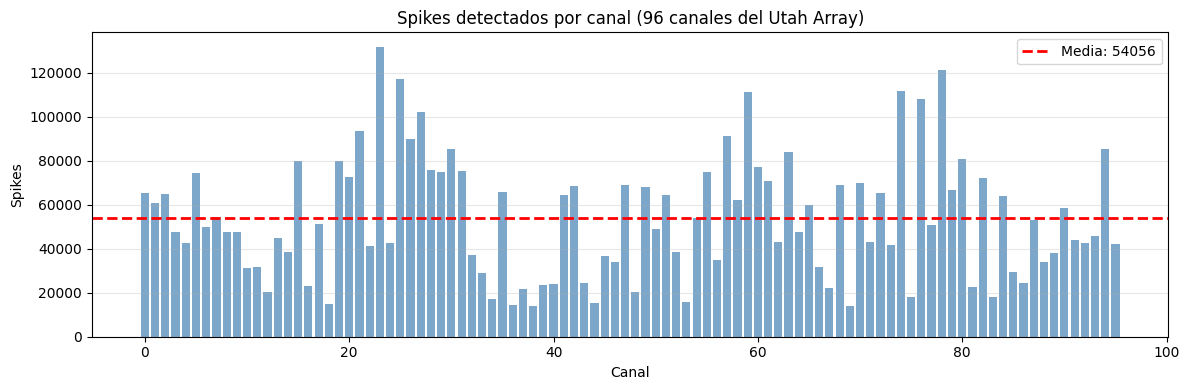

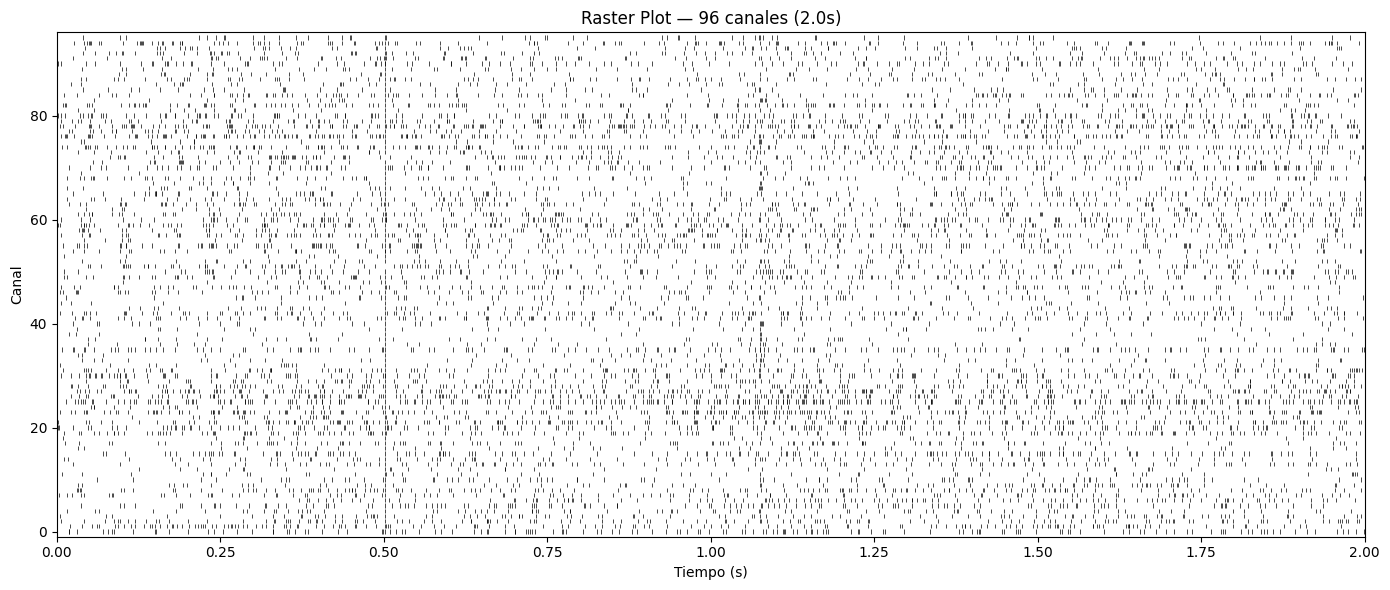

In [7]:
# ============================================================
# PASO 1: EXTENSIÓN A 96 CANALES  (Generación de MUA_matrix)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import decimate
import neo
from pathlib import Path


# -------------------------------------------- PARÁMETROS GLOBALES --------------------------------
data_path = Path("C:/Proyectos/TFG/data/i140703-001.ns6")
fs_original = 30000
fs = 10000
fs_output = 1000

# Parámetros spike detection
update_interval = 8912
threshold_mult = 4
refrac_period = 0.001
refrac_samples = int(refrac_period * fs)
bin_size = 0.001



# --------------------------------------------- CARGAR DATOS ---------------------------------------------

reader = neo.io.BlackrockIO(filename=str(data_path))
blk = reader.read_block(lazy=True, signal_group_mode='split-all')
seg = blk.segments[0]

#1) Filtro señales a 30 kHz
signals_30k = [s for s in seg.analogsignals 
               if int(s.sampling_rate.rescale('Hz').magnitude) == fs_original]

print(f"   Señales encontradas .ns6: {len(signals_30k)} canales")
print(f"   Duración: {signals_30k[0].duration}")

#2) Calculo número de bins (usar primer canal como referencia)
raw_sample = signals_30k[0].load()
N_30k = raw_sample.shape[0]
N_10k = N_30k // 3
duracion_total = N_10k / fs
n_bins = int(np.ceil(duracion_total / bin_size))

print(f"   Muestras @ 30 kHz: {N_30k:,}")
print(f"   Muestras @ 10 kHz: {N_10k:,}")
print(f"   Duración: {duracion_total:.2f} s")
print(f"   Bins MUA: {n_bins:,}")

# --------------------------------------------------------- FUNCIONES DEL PIPELINE -----------------------------------------------------

def filtro_mad(signal): #FUNCION PASO 1: Filtro MAD: y(n) = x(n) - 0.5[x(n-1) + x(n-2)]"""
    N = len(signal)
    filtered = np.zeros(N)
    filtered[0] = signal[0]
    filtered[1] = signal[1] - 0.5 * signal[0]
    
    for n in range(2, N):
        filtered[n] = signal[n] - 0.5 * (signal[n-1] + signal[n-2])
    
    return filtered


def calcular_threshold(signal_rect, update_interval, mult): #FUNCION PASO 3 y 4: Threshold adaptativo por ventanas
    N = len(signal_rect)
    n_ventanas = int(np.ceil(N / update_interval))
    threshold = np.zeros(N)
    
    for i in range(n_ventanas):
        start = i * update_interval
        end = min((i + 1) * update_interval, N)
        ventana = signal_rect[start:end]
        thresh = np.mean(ventana) * mult
        threshold[start:end] = thresh
    
    return threshold


def detectar_spikes_refractario(signal_rect, threshold, refrac_samples): #FUNCION PASO 5 y 6:  Detecta spikes con período refractario

    N = len(signal_rect)
    spike_indices = []
    last_spike = -refrac_samples
    
    for i in range(N):
        if signal_rect[i] > threshold[i]:
            if (i - last_spike) >= refrac_samples:
                spike_indices.append(i)
                last_spike = i
    
    return np.array(spike_indices)


def binning(spike_indices, fs, n_bins, bin_size): #FUNCION PASO 7: Convierte timestamps a bins de 1 ms
    MUA = np.zeros(n_bins, dtype=np.int8)
    
    if len(spike_indices) > 0:
        spike_bins = (spike_indices / (fs * bin_size)).astype(int)
        valid = spike_bins[spike_bins < n_bins]  # Filtrar bins fuera de rango
        MUA[valid] = 1  # Binario: refractario 1ms = bin 1ms, nunca hay >1 spike por bin
    
    return MUA



def procesar_canal(signal_raw): 
    
    # 0) Downsampling
    data_10k = decimate(signal_raw, q=3, ftype='fir')
    # 1) Filtro MAD
    signal_mad = filtro_mad(data_10k)
    # 2) Rectificación
    signal_rect = np.abs(signal_mad)
    # 3 Y 4) Threshold
    threshold = calcular_threshold(signal_rect, update_interval, threshold_mult)
    # 5 Y 6) Detección + refractario
    spike_indices = detectar_spikes_refractario(signal_rect, threshold, refrac_samples)
    # 7) Binning
    MUA = binning(spike_indices, fs, n_bins, bin_size)
    
    return MUA, len(spike_indices)


# --------------------------------------------------- PROCESAR  LOS 96 CANALES -----------------------------------------
print("\n Procesado de  96 canales:\n")

MUA_matrix = np.zeros((96, n_bins), dtype=np.int8)
spike_counts = np.zeros(96, dtype=int)

for canal in range(96):
    raw_signal = signals_30k[canal].load().magnitude.flatten()    # Cargar señal raw del canal
    MUA, n_spikes = procesar_canal(raw_signal)  # Procesar
    MUA_matrix[canal, :] = MUA # Guardar
    spike_counts[canal] = n_spikes
    
    # Print cada 10 canales
    if (canal + 1) % 10 == 0:
        print(f"   Canales {canal-8}-{canal+1} completados")

# Guardar resultado
output_file = 'MUA_matrix_96channels.npy'
np.save(output_file, MUA_matrix)
print(f"\n MUA_matrix guardado en: {output_file}")


# --------------------------------------------------- ESTADÍSTICAS GLOBALES ---------------------------------------------
print("\n" + "="*70)
print("ESTADÍSTICAS MUA_matrix")
print("="*70)

print(f"\n SHAPE Y FORMATO:")
print(f"   Shape: {MUA_matrix.shape}")
print(f"   Dtype: {MUA_matrix.dtype}")
print(f"   Tamaño en memoria: {MUA_matrix.nbytes / 1e6:.2f} MB")
print(f"   Valores únicos: {np.unique(MUA_matrix)}")

print(f"\n SPIKES POR CANAL:")
print(f"   Total spikes (todos los canales): {np.sum(spike_counts):,}")
print(f"   Media por canal: {np.mean(spike_counts):.1f} spikes")
print(f"   Std: {np.std(spike_counts):.1f}")
print(f"   Min: {np.min(spike_counts)} (canal {np.argmin(spike_counts)})")
print(f"   Max: {np.max(spike_counts)} (canal {np.argmax(spike_counts)})")

print(f"\n ACTIVIDAD GLOBAL:")
total_bins = 96 * n_bins
bins_activos = np.sum(MUA_matrix > 0)
print(f"   Total bins: {total_bins:,}")
print(f"   Bins con spikes: {bins_activos:,} ({bins_activos/total_bins*100:.2f}%)")
print(f"   Sparsity: {(1 - bins_activos/total_bins)*100:.2f}%")



# ------------------------------------------- GRÁFICA 1: Distribución de spikes por canal -------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(96), spike_counts, color='steelblue', alpha=0.7)
ax.axhline(np.mean(spike_counts), color='red', ls='--', lw=2, 
           label=f'Media: {np.mean(spike_counts):.0f}')
ax.set_xlabel('Canal')
ax.set_ylabel('Spikes')
ax.set_title('Spikes detectados por canal (96 canales del Utah Array)')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
#------------------------------------------- GRÁFICA 2: Raster plot de los 96 canales -------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))
t_vis = 2.0

for canal in range(96):
    spikes = np.where(MUA_matrix[canal, :int(t_vis * fs_output)] > 0)[0] / fs_output
    if len(spikes) > 0:
        ax.vlines(spikes, canal - 0.4, canal + 0.4, colors='black', linewidths=0.5)

ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Canal')
ax.set_title(f'Raster Plot — 96 canales ({t_vis}s)')
ax.set_xlim(0, t_vis)
ax.set_ylim(-1, 96)
plt.tight_layout()
plt.show()